In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots                 # pip install SciencePlots

plt.style.use(['science', 'no-latex'])

In [167]:
# ── Cell 3: Discover & sort CSV batch files ───────────────────────────────────
# ── Cell 2: User Parameters ───────────────────────────────────────────────────
# ↓ Edit these three values before running the rest of the notebook

EVENTS_FOLDER    = r"C:\Arjun\Thesis\data\20200421_170039-sunset1\filtered chunks"   # folder containing events_batch_*.csv
START_TIMESTAMP  = 1587452621.57     # start of integration window  (same units as CSV timestamps)
TIME_PERIOD      = 0.1      # duration of integration window (same units)

# Derived stop threshold
END_TIMESTAMP = START_TIMESTAMP + TIME_PERIOD

# DAVIS resolution
WIDTH, HEIGHT = 346, 260

print(f"Integrating events from t={START_TIMESTAMP} to t={END_TIMESTAMP}")


pattern = os.path.join(EVENTS_FOLDER, "events_batch_*.csv")

csv_files = sorted(glob.glob(pattern))          # lexicographic sort matches zero-padded names

if not csv_files:

    raise FileNotFoundError(f"No CSV files matched: {pattern}")

print(f"Found {len(csv_files)} batch files.")

print("  First:", os.path.basename(csv_files[0]))

print("  Last :", os.path.basename(csv_files[-1]))

Integrating events from t=1587452621.57 to t=1587452621.6699998
Found 537 batch files.
  First: events_batch_00000.csv
  Last : events_batch_00536.csv


In [168]:
event_counts = np.zeros((HEIGHT, WIDTH, 2), dtype=np.int32)

total_events_used = 0
stop_early        = False

for csv_path in csv_files:
    if stop_early:
        break

    df = pd.read_csv(
        csv_path,
        usecols=['x', 'y', 'polarity', 'timestamp'],
        dtype={'timestamp': np.float64, 'x': np.int16, 'y': np.int16, 'polarity': str}
    )

    if df['timestamp'].max() < START_TIMESTAMP:
        del df
        continue

    if df['timestamp'].min() > END_TIMESTAMP:
        stop_early = True
        del df
        break

    mask = (df['timestamp'] >= START_TIMESTAMP) & (df['timestamp'] < END_TIMESTAMP)

    if (df['timestamp'] >= END_TIMESTAMP).any():
        stop_early = True

    df_win = df[mask]
    del df

    if df_win.empty:
        del df_win
        continue

    xs  = df_win['x'].to_numpy().clip(0, WIDTH  - 1)
    ys  = df_win['y'].to_numpy().clip(0, HEIGHT - 1)
    pol = df_win['polarity'].str.strip().str.upper() == 'TRUE'
    del df_win

    on_mask  =  pol
    off_mask = ~pol

    np.add.at(event_counts[:, :, 0], (ys[on_mask],  xs[on_mask]),  1)
    np.add.at(event_counts[:, :, 1], (ys[off_mask], xs[off_mask]), 1)

    total_events_used += len(xs)
    print(f"  {os.path.basename(csv_path)} — {len(xs)} events added  "
          f"({'early stop' if stop_early else 'continue'})")

print(f"\nDone. Total events accumulated: {total_events_used:,}")
# ── Cell 5: Build the visualisation frames ────────────────────────────────────
on_counts  = event_counts[:, :, 0].astype(np.float32)
off_counts = event_counts[:, :, 1].astype(np.float32)
total      = on_counts + off_counts

print(f"ON  peak count : {int(on_counts.max())}")
print(f"OFF peak count : {int(off_counts.max())}")
print(f"Total peak     : {int(total.max())}")

  events_batch_00017.csv — 14636 events added  (continue)
  events_batch_00018.csv — 15380 events added  (early stop)

Done. Total events accumulated: 30,016
ON  peak count : 10
OFF peak count : 8
Total peak     : 16


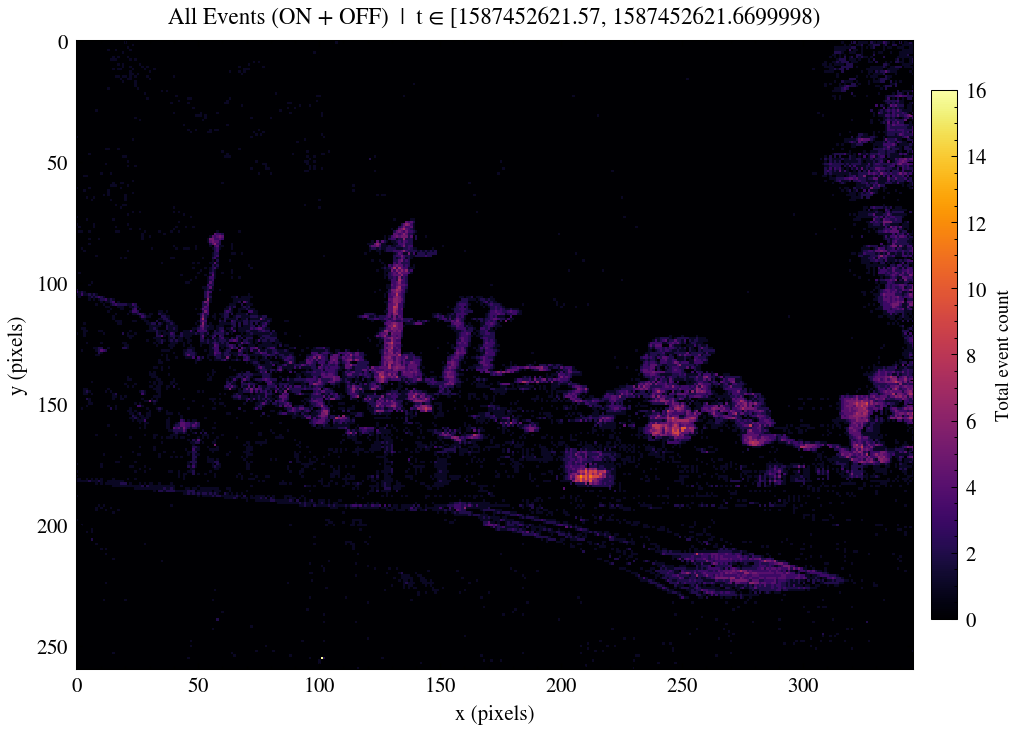

In [ ]:
# ── Cell 8: Plot — Combined total event density (grey scale) ──────────────────
fig, ax = plt.subplots(figsize=(7, 5.3), dpi=150)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# No masking — zero counts shown as light grey, high counts as black
im = ax.imshow(
    total,
    cmap='inferno',          # grey scale: 0 counts = white, max counts = black
    origin='upper',
    vmin=0,
    vmax=total.max(),
    interpolation='nearest',
    aspect='equal'
)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Total event count', color='black', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')

#ax.set_title(f'All Events (ON + OFF)  |  t ∈ [{START_TIMESTAMP}, {END_TIMESTAMP})',
             #color='black', fontsize=11, pad=8)
ax.set_xlabel('x (pixels)', color='black')
ax.set_ylabel('y (pixels)', color='black')
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.savefig('events_total.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

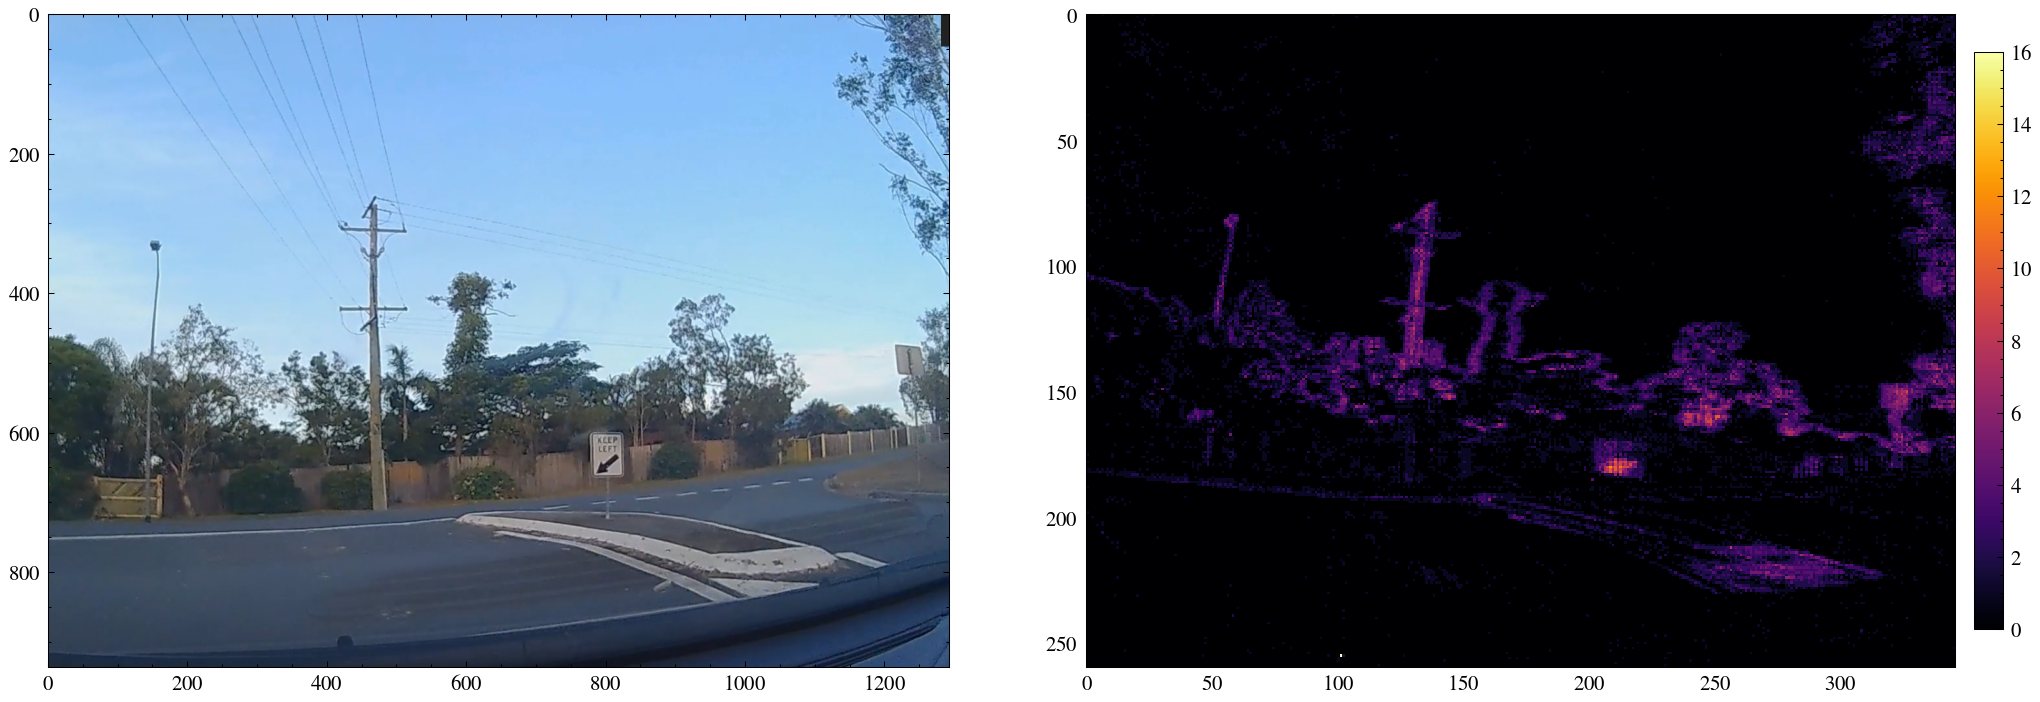

In [184]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Load your other image from computer
left_image_path = r"C:\Arjun\Thesis\Draft\figures\Screenshot (31).png"  # Change this to your image path
left_img = mpimg.imread(left_image_path)
 # ← ADD THIS before adding text
# Create figure with two subplots side by side
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5.3), dpi=150)
plt.subplots_adjust(bottom=0.15) 
plt.subplots_adjust(wspace=0.3)
# ========== LEFT PLOT (your stored image) ==========
ax_left.imshow(left_img)
#ax_left.set_title('Your Stored Image', color='black', fontsize=11, pad=8)
#ax_left.set_xlabel('Video Frame (RGB)', color='black',fontsize=20)
#ax_left.set_ylabel('y (pixels)', color='black')
ax_left.tick_params(colors='black')
for spine in ax_left.spines.values():
    spine.set_edgecolor('black')
ax_left.set_facecolor('white')

# Add text below left image
'''ax_left.text(0.5, -0.15, '', 
             transform=ax_left.transAxes, 
             fontsize=20, color='black', 
             ha='center', va='top')'''

# ========== RIGHT PLOT (your existing total events plot) ==========
ax_right.set_facecolor('white')
fig.patch.set_facecolor('white')

im = ax_right.imshow(
    total,
    cmap='inferno',
    origin='upper',
    vmin=0,
    vmax=total.max(),
    interpolation='nearest',
    aspect='equal'
)

cbar = fig.colorbar(im, ax=ax_right, fraction=0.03, pad=0.02)
#cbar.set_label('Total event count', color='black', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')

#ax_right.set_title(f'All Events (ON + OFF)  |  t ∈ [{START_TIMESTAMP}, {END_TIMESTAMP})',
                   #color='black', fontsize=11, pad=8)
#ax_right.set_xlabel('Event accumulation over 0.1 s', color='black', fontsize=20)
#ax_right.set_ylabel('y (pixels)', color='black')
ax_right.tick_params(colors='black')
for spine in ax_right.spines.values():
    spine.set_edgecolor('black')
# Add centered text below both images
#fig.text(0.5, 0.05, 'Time stamp: 17:03:41 21-04-2020, Traverse: sunset1', 
         #fontsize=20, color='black', 
         #ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for text below images
plt.savefig('combined_images.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()